# Partial Differential Equations Part II. 

So far we've discussed the
 [3 broad classes of PDEs](https://en.wikiversity.org/wiki/Partial_differential_equations#Elliptic,_Hyperbolic,_and_Parabolic_PDEs): hyperbolic, elliptic, and parabolic PDEs.  

And discussed the following methods for solving BVP PDEs:
+ Jacobi Method (Relaxation)
+ Gauss-Seidel 
+ Overrelaxation 

For solving an elliptic PDE like the Laplace Equation. 

Today, we'll tackle the other kind of PDEs: IVPs

## Initial Value Problem PDEs
For the two other classes of PDEs: hyperbolic and parabolic, we have derivatives in both space and time. 
For these problems, we typically have an initial condition defined at all points on the grid. 

While we have BCs defined in space for the initial conditions, we don't have a boundary condition in the time dimension to constrain a solution for these problems with relaxation as we did before. 

## Ex: Heat Diffusion Equation
Let's consider the one-dimensional diffusion equation:

$$\frac{\partial \phi}{\partial t} = D \frac{\partial^{2} \phi}{\partial x^{2}}$$

Where $D$ is some constant diffusion coefficient and the function $\phi(x,t)$ depends on two independent variables $x$ and $t$. (A **parabolic** PDE by definition!)

This is also the form of the heat equation, in which case $\phi$ would represent the temperature inside of a solid as a function of location and time, given some initial $\phi(x,0)$ defined at every point and the boundaries maintained consistently throughout.

Let's assume a slab initially at $T_0$, with fixed temperature on the left $T_L$ and on the right $T_R$. 

### FTCS: Forward-Time Centered Space method 
+ Just like as before, we can discretize the second spatial derivative with a centered difference scheme:
    $$\frac{\partial^{2} \phi}{\partial x^{2}} = \frac{\phi(x + \Delta x, t) + \phi(x - \Delta x, t) - 2\phi(x, t)}{\Delta x^{2}}$$
    Then, the diffusion equation becomes a system of simultaneous ODEs (one ODE per spatial location) which we can solve with any ODE method to step forward in time. 
+ Discretize in time with forward Euler (our spatial discretization scheme has second order error, a higher order scheme in time would be of no benefit.)
    $$\phi(x,t+\Delta t)=\phi(x,t)+\Delta t \frac{D}{\Delta x^{2}}[\phi(x+\Delta x,t)+\phi(x-\Delta x,t)-2\phi(x,t)]$$
+ Apply the initial conditions $\phi(x,0)$ and advance through time for each cell in the grid. Maintain the values at the boundaries to the fixed boundary conditions. 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_8-4
```

## Ex: Hyperbolic PDEs
Now let's see about the other class of IVP PDEs: hyperbolic PDEs.

Consider the linear advection equation:
$$\frac{\partial a}{\partial t} + u \frac{\partial a}{\partial x} = 0$$

which describes the transport of some quantity $a$ in a flow of speed $u$. 

(You can think of $a$ as any property that could be carried by a flow. For example, if you dropped colored dye into a river, $a$ would represent the concentration of dye over time)

Let's say we have some sort of initial condition $a(x,t=0) = a_0(x)$. If the flow speed $u$ is constant, in this simple case, we can expect that the exact solution is just a translation in space by some displacement: $a(x,t) = a(x-ut)$. 


```{note} What is advection?
:class: dropdown
In the fluid approximation, in which we represent quantities in terms of their volume densities, the three major conservation laws (mass, momentum, energy) are written as:
\begin{align*}
\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho {\bf u}) &= 0 \\
\frac{\partial (\rho {\bf u})}{\partial t} + \nabla \cdot (\rho {\bf u}{\bf u}) + \nabla P 
&= 0 \\
\frac{\partial (\rho E)}{\partial t} + \nabla \cdot (\rho {\bf u} E + {\bf u} P) &= 0
\end{align*}

Where $\rho$ is the mass density, ${\bf u}$ is the velocity field, $P$ is the pressure, and $E$ is the energy density per volume. 

And, not to be confused with the Euler method, these are also sometimes called the [Euler Equations](https://en.wikipedia.org/wiki/Euler_equations_(fluid_dynamics)#Euler_equations). 

If you expand out the first equation in one dimension and apply the condition for incompressible flow: $\Nabla \cdot {\bf u} = 0$, conservation of mass takes on the form of the advection equation:

$$\frac{\partial \rho}{\partial t} + u \frac{\partial \rho}{\partial x} = 0 $$

Which just tells us that within a volume, the change of mass over time (1st term) is described by advection (the second term): the flow of mass at some speed $u$ across the volume. That is, putting mass in a box will increase the amount of mass in that box... mass conservation!

If you expand these out, you can see that all of these equations have an advection term for the conserved quantity to describe flow behavior in terms of conservation. Thus, solving advection equations is key for hydrodynamics!
```

Now, if wanted to discretize with the FTCS method as before, we would end up with the following scheme:
$$a(x, t+\Delta t) = a(x,t) -  \frac{u \Delta t}{2 \Delta x} [a(x+\Delta x, t) - a(x-\Delta x, t)]$$


Let's try out a simulation for advection. We'll start with a tophat profile for the initial conditions:

$$ a_0(x) = \biggl\lbrace 
\begin{array}{ll}
  1 & \qquad {\rm if \  L/3 \leq x \leq 2L/3,} \\
  0  & \qquad{\rm if \ x < L/3 \ or \ x>2L/3.}
\end{array} $$

And apply the FTCS discretization. Let's assume that our domain has size $L=1$ and $u=0.1$ and find the solution at $t=1$. 

One of the first things you'll notice is that the solution looks ... pretty bad. 

You can play around with the number of grid cells and the size of the timestep and it will still look pretty bad!

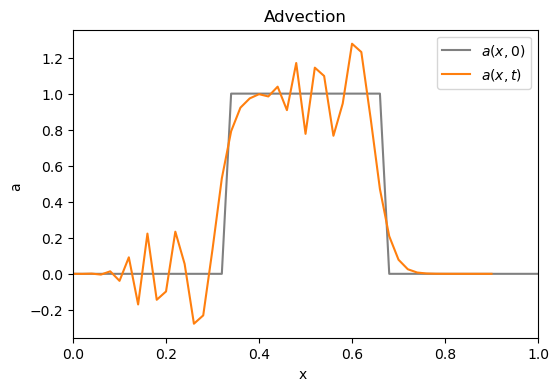

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def FTCS_advection(u,time,N=100,dt=0.1):
    dx = L/N       # Grid spacing
    epsilon = dt/1000
    x_points = np.linspace(0,L,num=N+1) # x coordinates of the points
    # initial conditions
    a_0 = np.ones_like(x_points) 
    a_0[x_points< L/3.] = 0.0
    a_0[x_points> 2*L/3.] = 0.0

    # Create arrays for the current and updated a
    a = np.empty(N+1,float)
    a[:] = a_0[:]

    ap = np.empty(N+1,float)
    ap[0] = a[N]
    ap[N] = a[0]

    # Main loop
    k = 0
    t = 0.0
    c = dt*u/dx

    while t < time:
        # Calculate the new values of T at each grid point
        for i in range(1,N):
            ap[i] = a[i] - c*0.5*(a[i+1] - a[i-1])
        # Periodic BCs
        ap[0] = a[N]
        ap[N] = a[0]
        # update and advance
        a[:] = ap[:]
        t += dt
    return x_points, a_0, a

L = 1.0
u = 0.1
dt = 0.001
N = 50
time = 1

fig, ax = plt.subplots(1,1, figsize=(6,4))
x_points, a_init, a_t = FTCS_advection(u,time,N,dt)

ax.plot(x_points ,a_init,color='gray',label=r'$a(x,0)$')

ax.plot(x_points - u*time ,a_t, label=r'$a(x,t)$',color='C1')

ax.legend()
ax.set_xlabel("x ")
ax.set_ylabel("a ")
ax.set_title('Advection')
ax.set_xlim(0,L)
plt.show()

### FTCS Stability Analysis 
So what's going on? Why does the FTCS scheme fail here?

Let's take  a good look at the scheme again:
$$a(x, t+\Delta t) = a(x,t) -  \frac{u \Delta t}{2 \Delta x} [a(x+\Delta x, t) - a(x-\Delta x, t)]$$

That means it's, of course, once again, time to bring out our trusty Taylor expansions. 

We know the derivative expanded in time:
$$\partial_t a(x,t) = \frac{a(x,t + \Delta t) - a(x,t)}{\Delta t} - \frac{1}{2} \Delta t \partial_{tt} a(x,t) + \ldots$$

where:

$$ a(x,t + \Delta t) = a(x,t)  - \Delta t \partial_t a(x,t) + \frac{1}{2} \Delta t^2 \partial_{tt} a(x,t) + \ldots$$

We can use our advection equation definition to replace higher order derivatives, where:
$$ \partial_t a = -u \partial_x a$$
implies
$$\partial_{tt} a = -u \frac{\partial}{\partial t} \frac{\partial a}{\partial x} = u^2 \partial_{xx} a$$

$$ a(x,t + \Delta t) = a(x,t)  - u \Delta t \partial_x a(x,t) + \frac{1}{2} u \Delta t^2 \partial_{xx} a(x,t) + \ldots$$

And we can use the expansion for centered differences from week 4:
$$ \frac{a(x + \Delta x) - a(x - \Delta x)}{2\Delta x} = \partial_x a + \mathcal{O}(\Delta x^2)$$

which tells us that:
$$ a(x,t + \Delta t) = a(x,t)  - \frac{u \Delta t}{2\Delta x}(a(x + \Delta x) - a(x - \Delta x)) + \frac{1}{2} u \Delta t^2 \partial_{xx} a(x,t) + \ldots$$

Now, we can see that the remaining difference between FTCS and the expanded derivative results in a truncation error term:
$$\partial_t a + u \partial_x a = -\frac{1}{2} u \Delta t^2 \partial_{xx} a(x,t) + \ldots$$

Looking at it we know it has the form of a diffusion term, but the truncation is *negative* diffusion, which is not only unphysical, but makes the FTCS scheme for hyperbolic equations numerically  **unstable**: numerical error will grow over time. 

### Upwinding
Now, FTCS assumes a centered difference scheme for the spatial derivative. 

In week 4, we learned that we can actually write derivatives in terms of forward or backward differences as well. 

If you recall from earlier in the week, solutions to hyperbolic PDEs have a distinct propagation speed. 

*Upwind Difference* is a discretization scheme that leverages information about the solution speed to come up with a numerically stable discretization -- we use information from the direction that it is flowing (upwind) to calculate the derivative:

If $u > 0$, we want to use information from cells to the left of the current one to calculate the derivative:
$$ \partial_x a(x,t) \approx \frac{a(x,t) - a(x-\Delta x, t)}{\Delta x} + \mathcal{O}(\Delta x)$$

If $u < 0$, the upwind information is to the right of the current cell:
$$ \partial_x a(x,t) \approx \frac{a(x + \Delta x,t) - a(x, t)}{\Delta x} + \mathcal{O}(\Delta x)$$

```{note} Stability Criterion for Advection
If you do the same stability analysis on the upwind scheme, you end up with a truncation error term like so:

$$ \partial_t a + u \partial_x a = \frac{1}{2} u \Delta x (1 - C) \partial_{xx} a + \mathcal{O}(\Delta x^2) + \mathcal{O}(\Delta t^2)$$

where $C$ is known as the [Courant number](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition):
$$C = \frac{u\Delta t}{\Delta x}$$

In which, the scheme remains stable (truncation term remains positive) as long as $C < 1$, which is the stability criterion knowns as the Courant-Friedrichs-Lewy (CFL) condition. 

Notice that $C$ is the ratio of the distance traversed by a flow in a single timestep to the size of the cell. In practice, this means that your timestep has to either be small enough or your grid cell large enough, such that the solution remains valid for the cell it is in.

In hydrodynamics, this is typically accomplished by adaptive timestepping in which $\Delta t$ is calculated after each timestep using the CFL parameter, the grid cell spacing, and the maximum velocity on the grid. 
```






<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_8-5
```